In [1]:
import ptime

import showdata
import numpy as np
start = "/bigdata/hplsim/production/marqua27/"
end = "/simOutput/openPMD/simData_%T.bp"
filename = start+"vacuum_propagation/flfoc_098_PIC"+end

iteration: 1104000
absolute maximum: 2420352500000.0


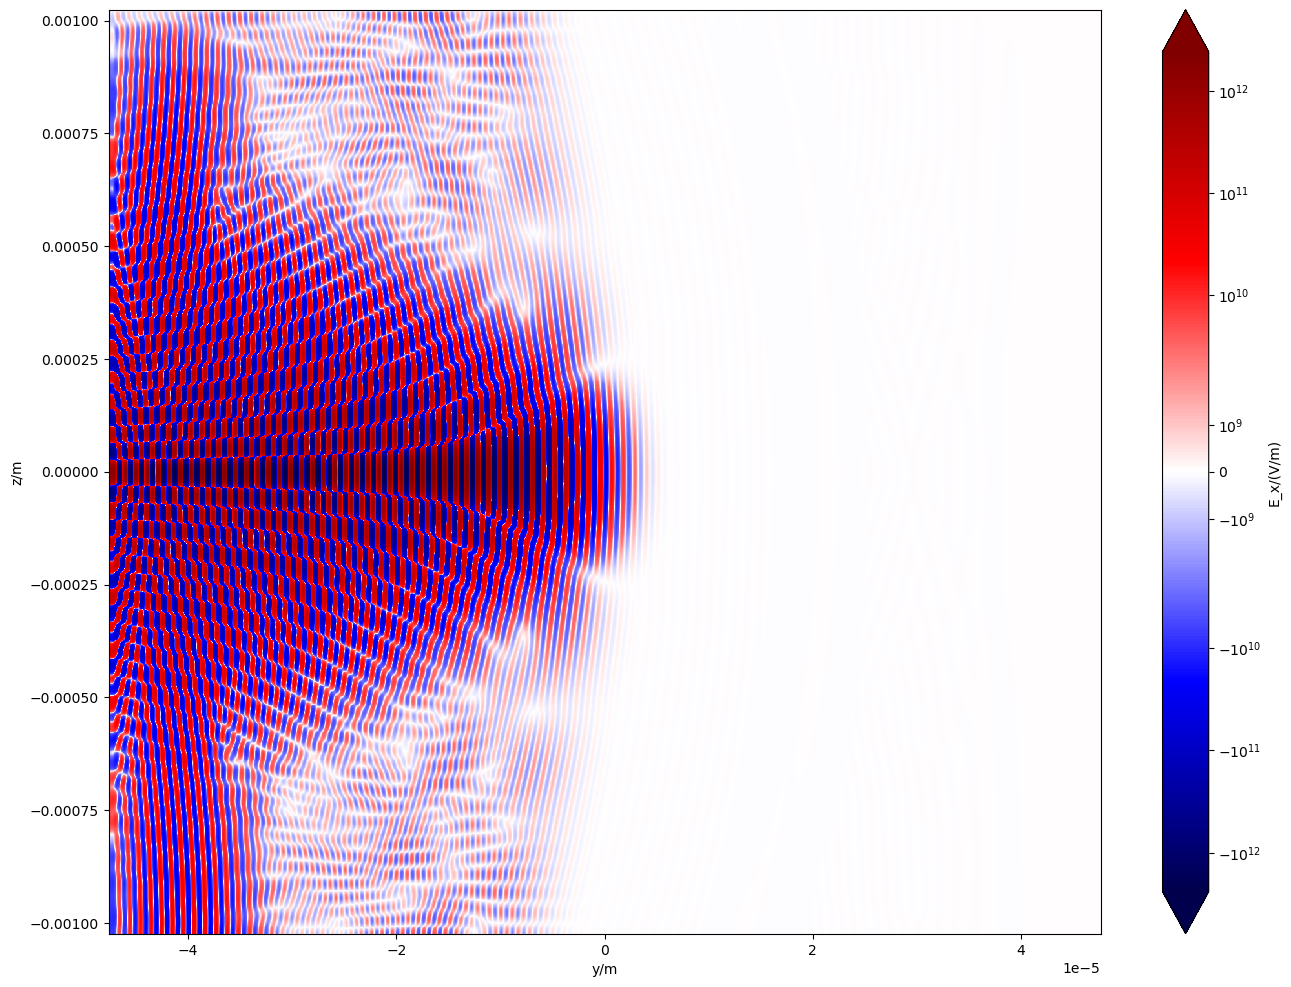

time showing file: 4.2321 s
iteration: 1110000
absolute maximum: 2420602000000.0


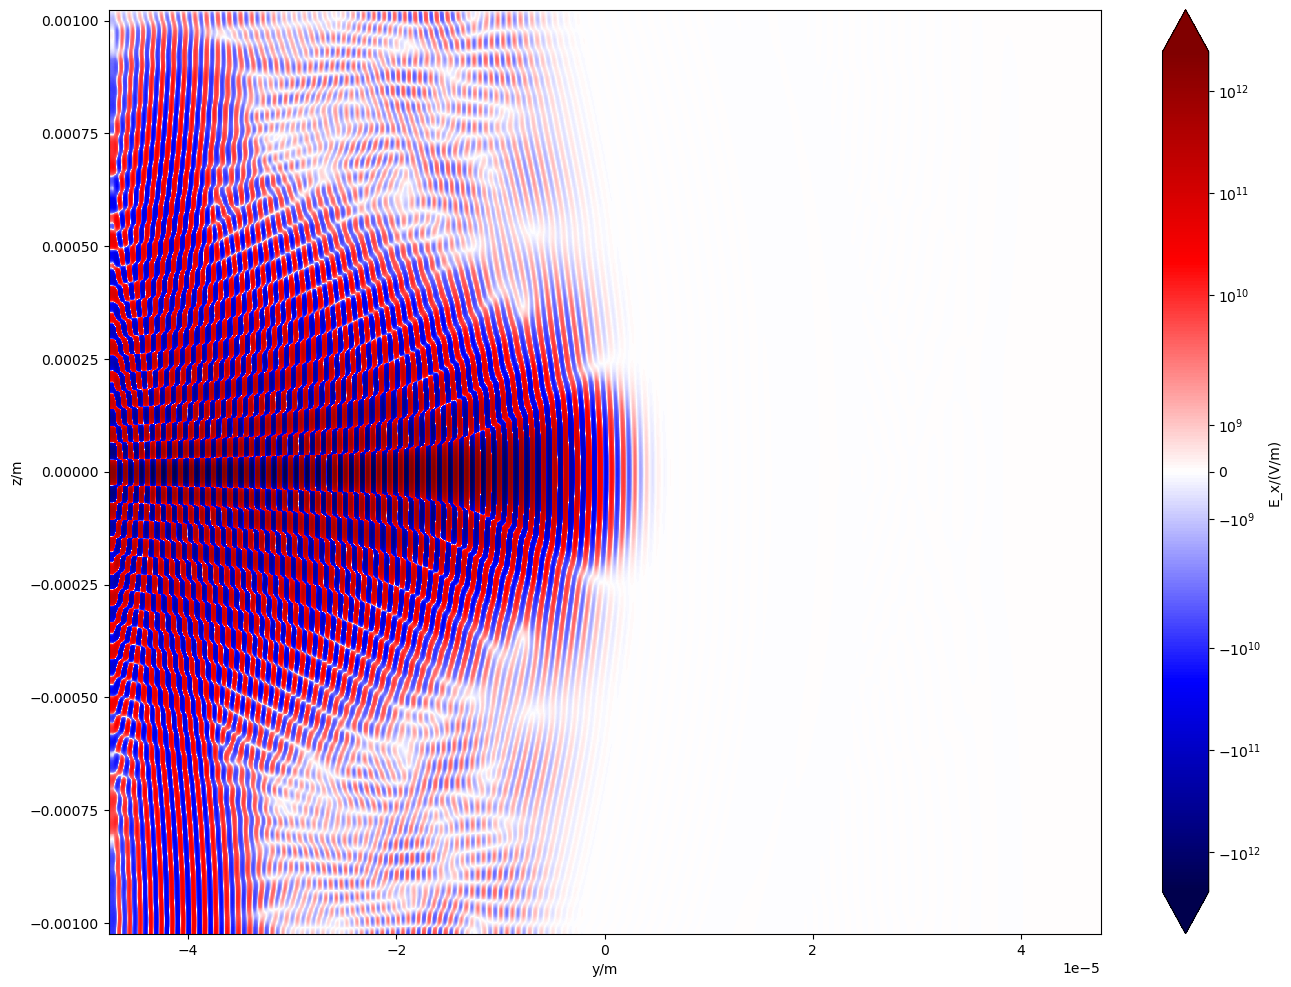

time showing file: 8.5704 s
iteration: 1116000
absolute maximum: 2414103200000.0


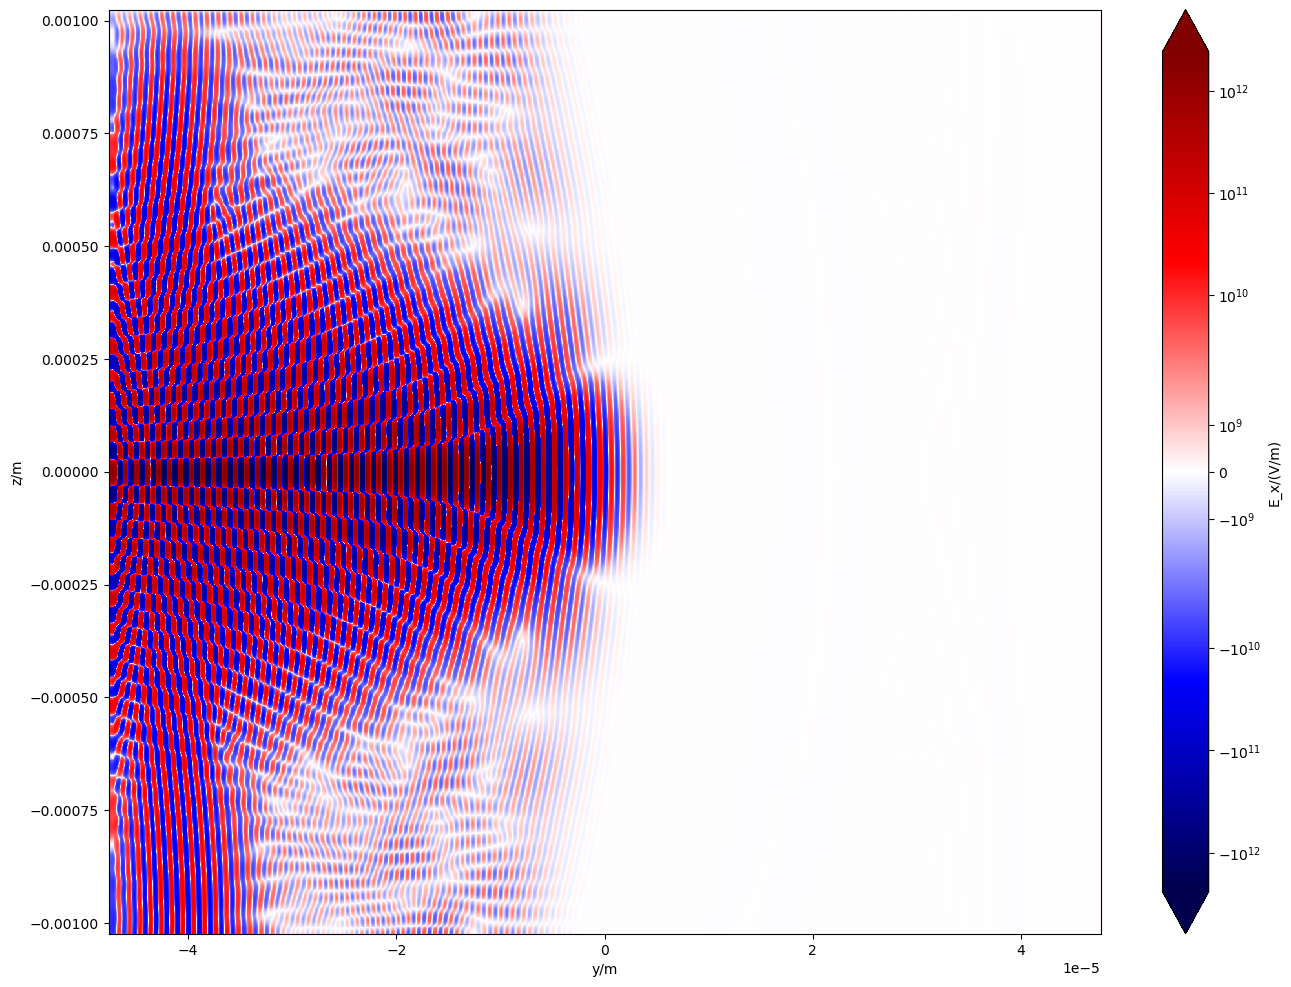

time showing file: 11.005 s
iteration: 1122000
absolute maximum: 2400527800000.0


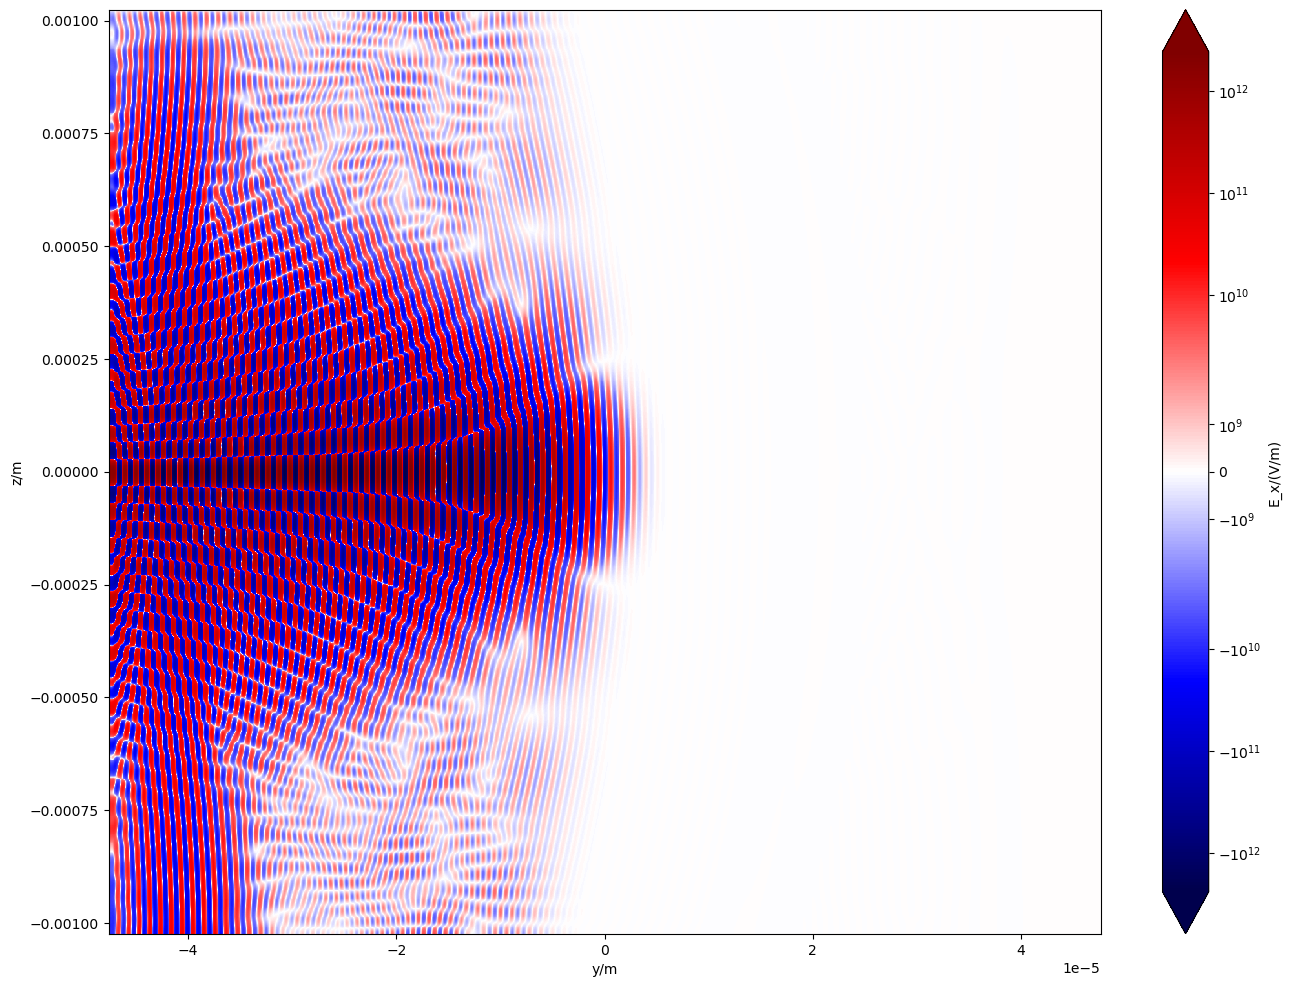

time showing file: 15.216 s
iteration: 1128000
absolute maximum: 2389733800000.0


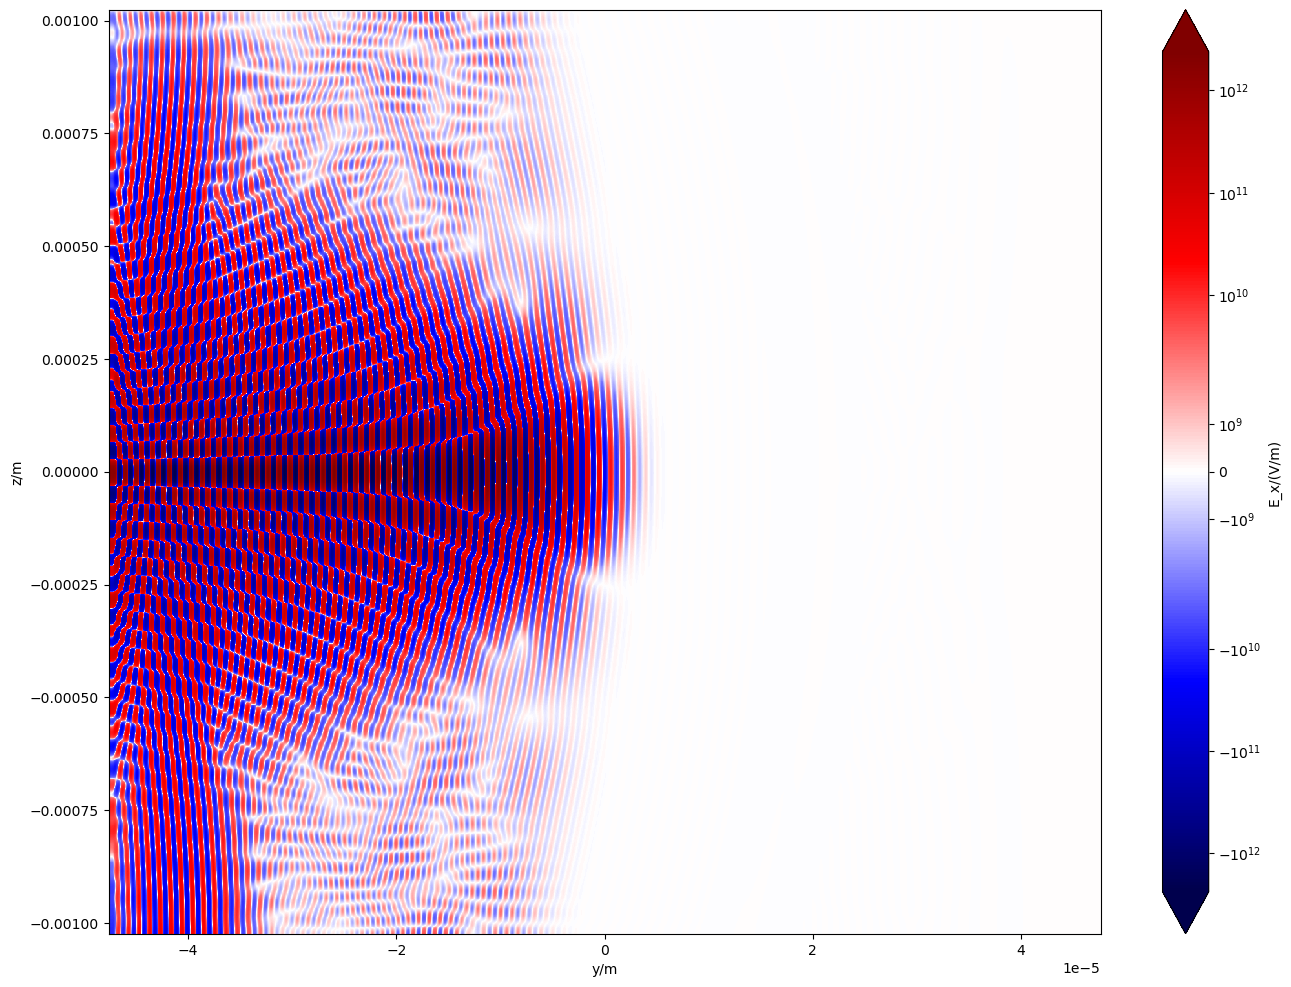

time showing file: 17.815 s
iteration: 1134000
absolute maximum: 2385822400000.0


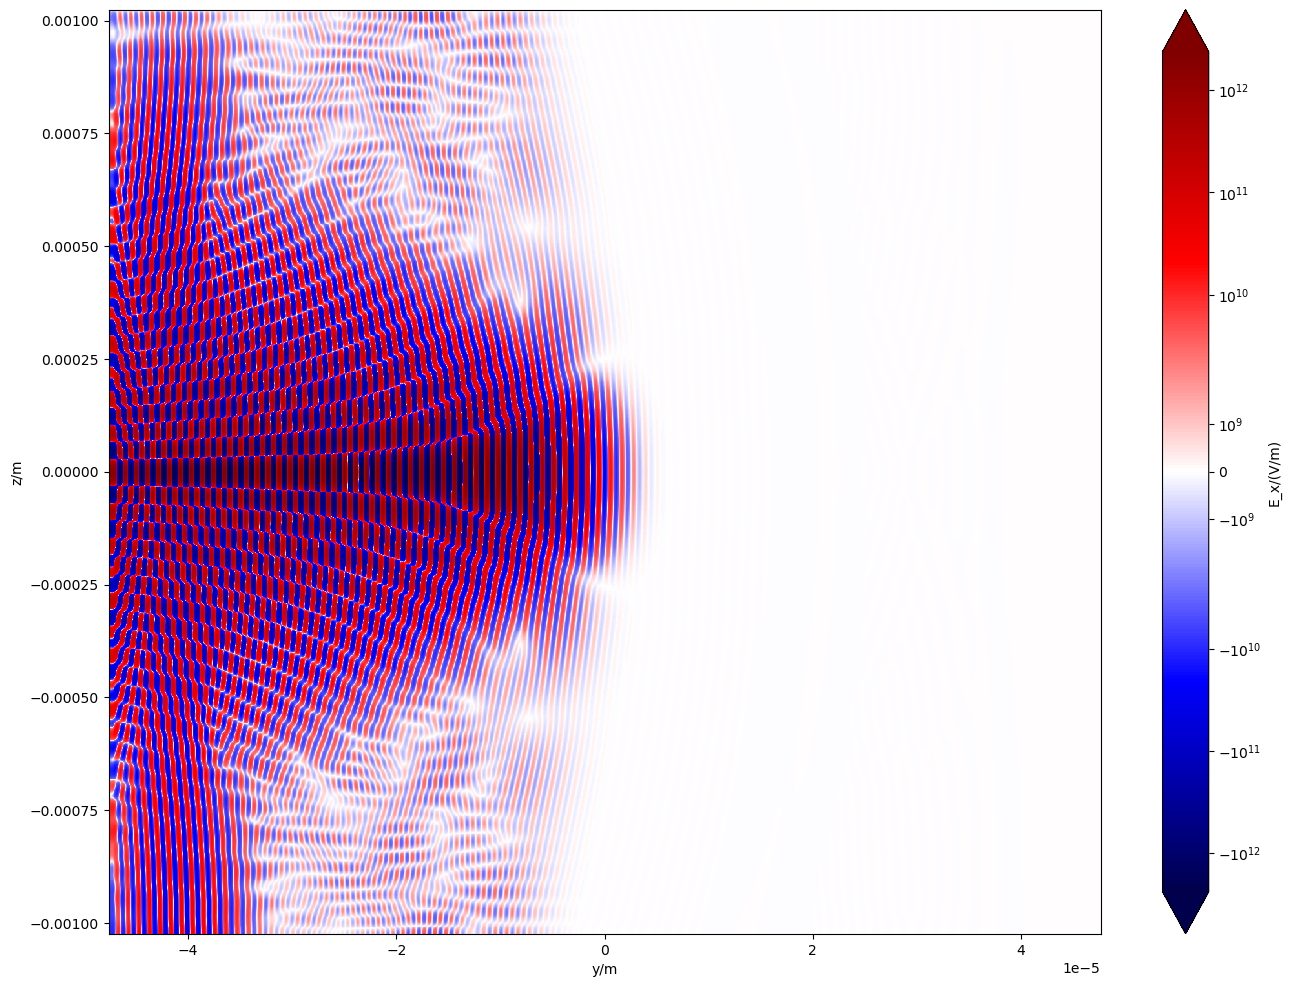

time showing file: 21.776 s
iteration: 1140000
absolute maximum: 2375065800000.0


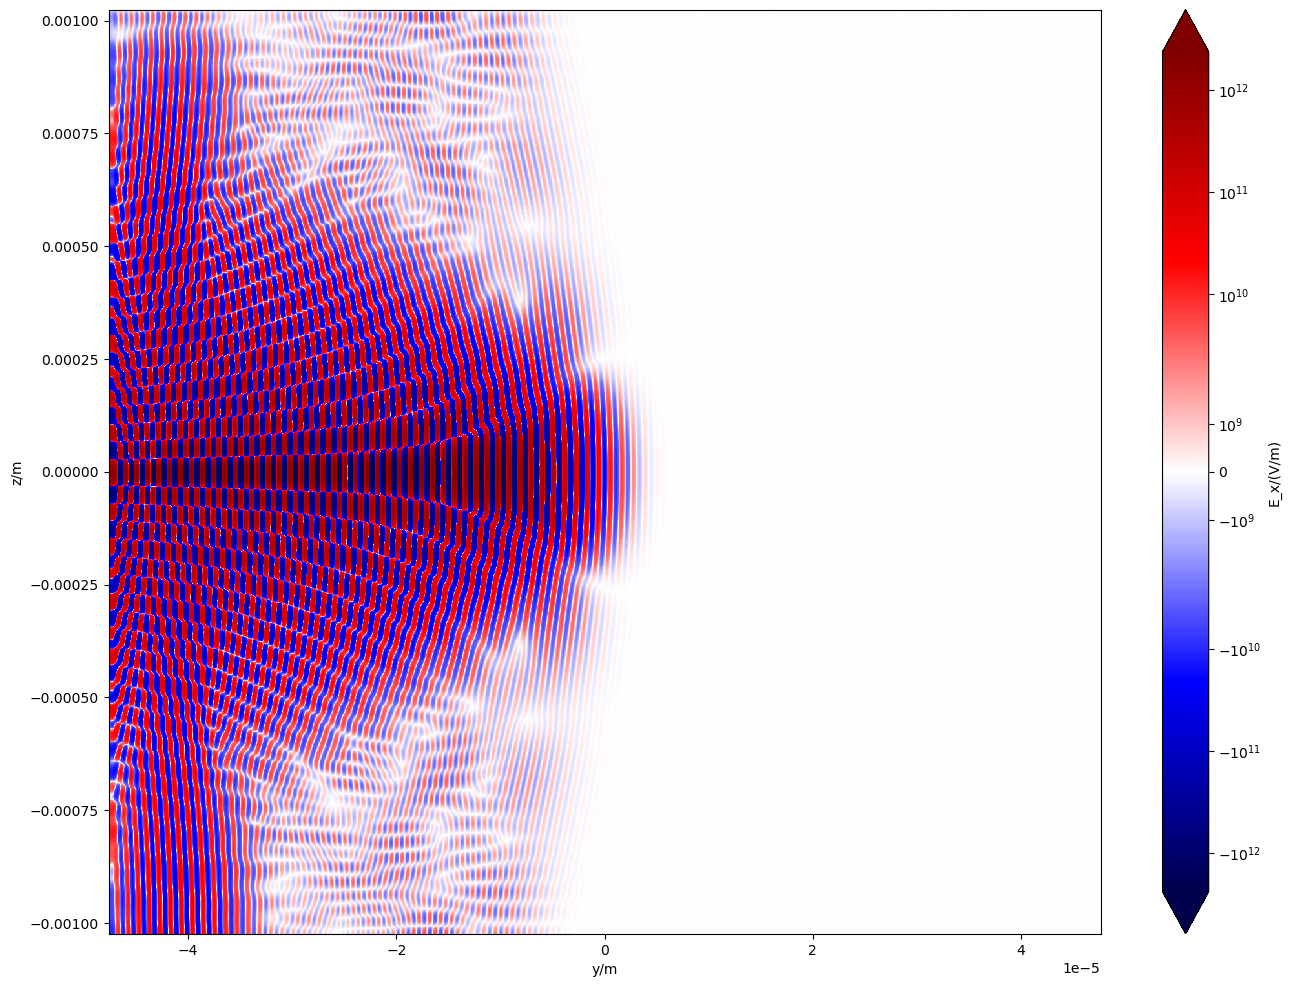

time showing file: 23.886 s
iteration: 1146000
absolute maximum: 2361228000000.0


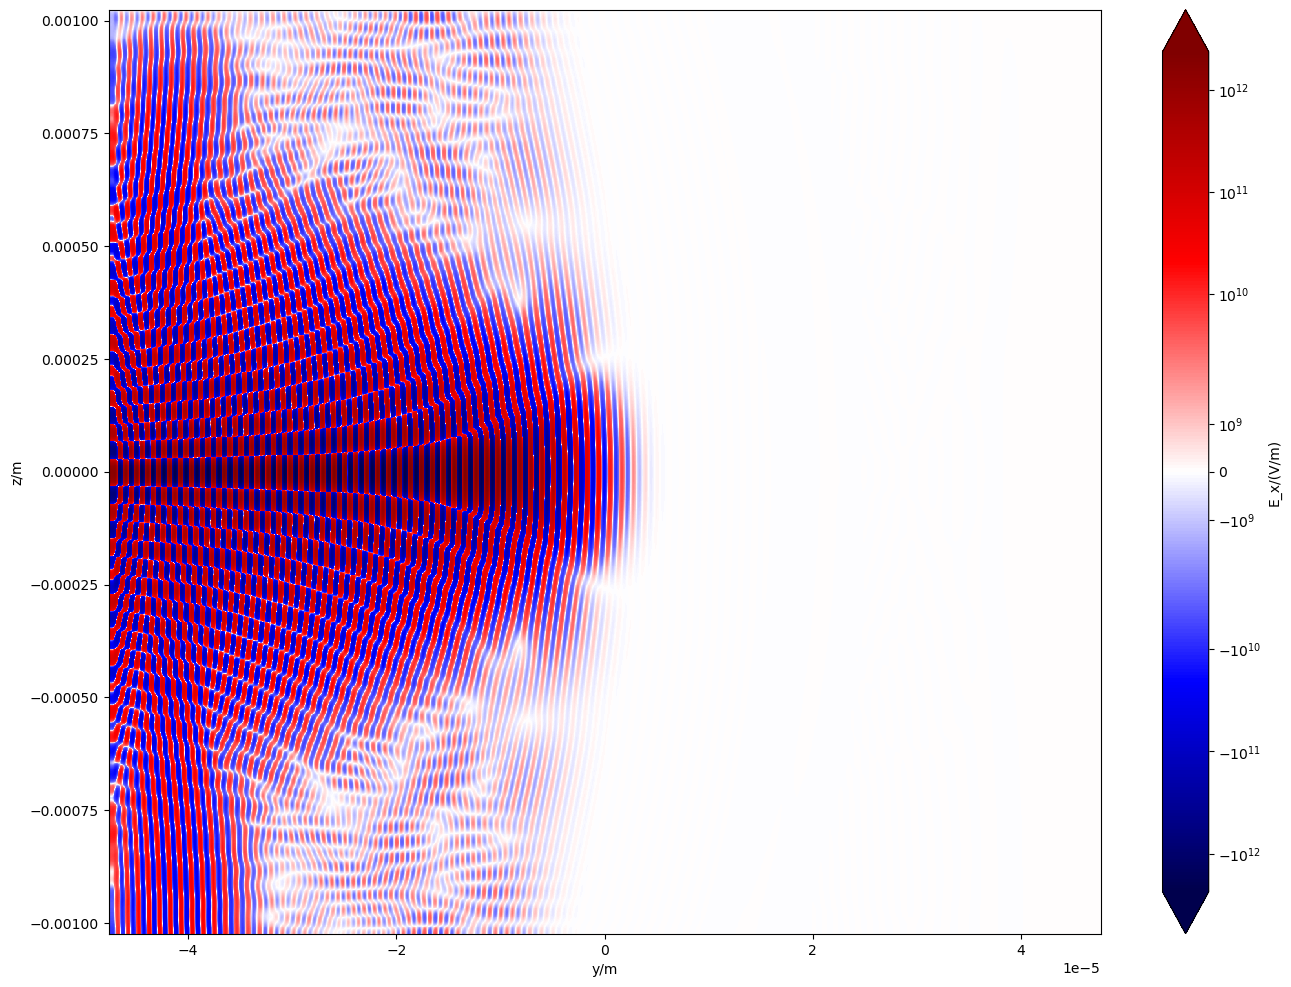

time showing file: 26.202 s
iteration: 1152000
absolute maximum: 2347725800000.0


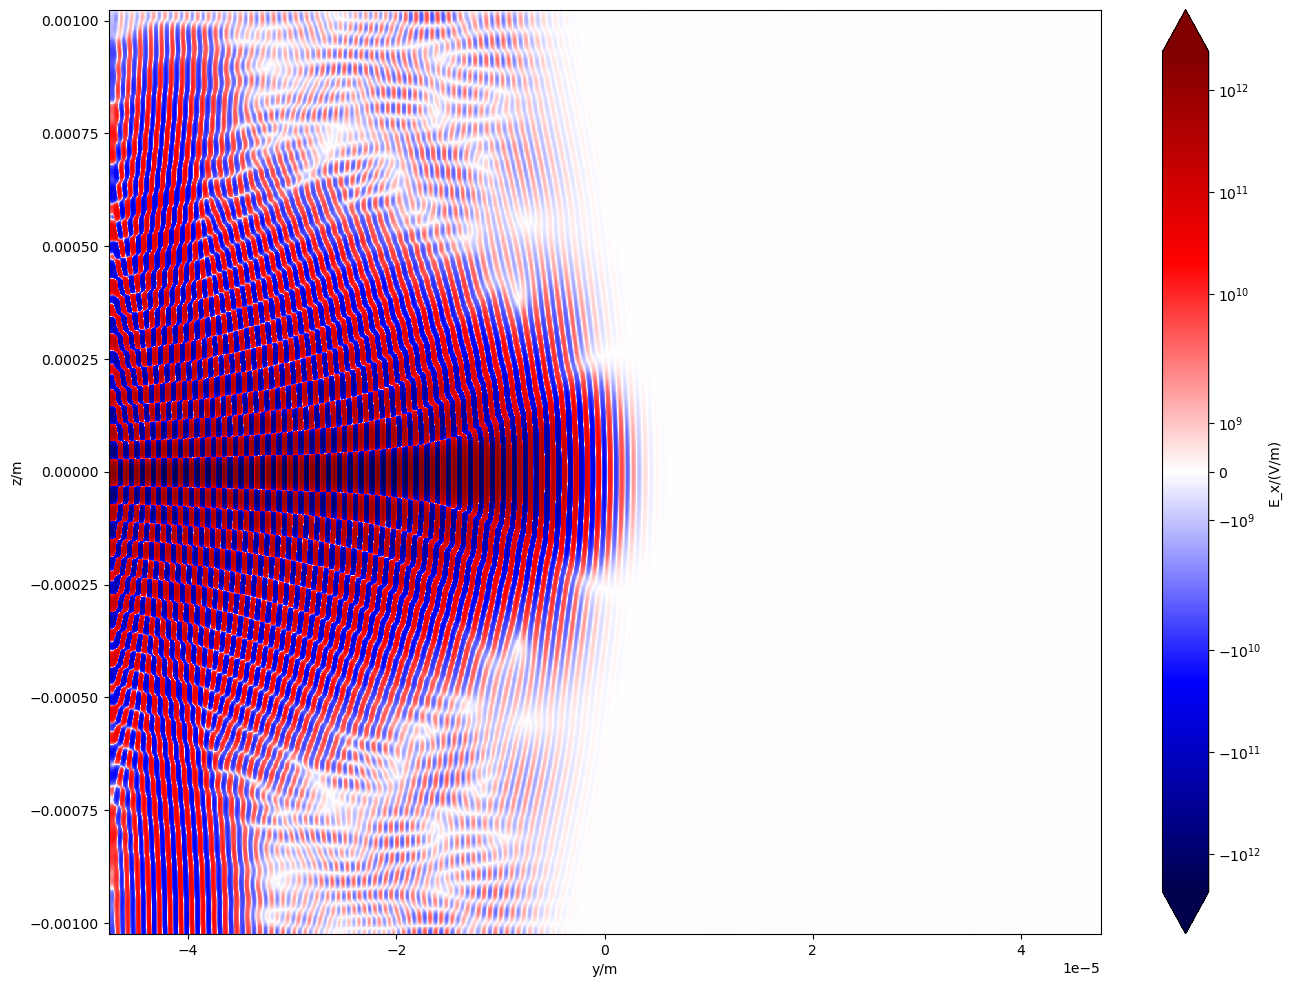

time showing file: 28.674 s
iteration: 1158000
absolute maximum: 2340400100000.0


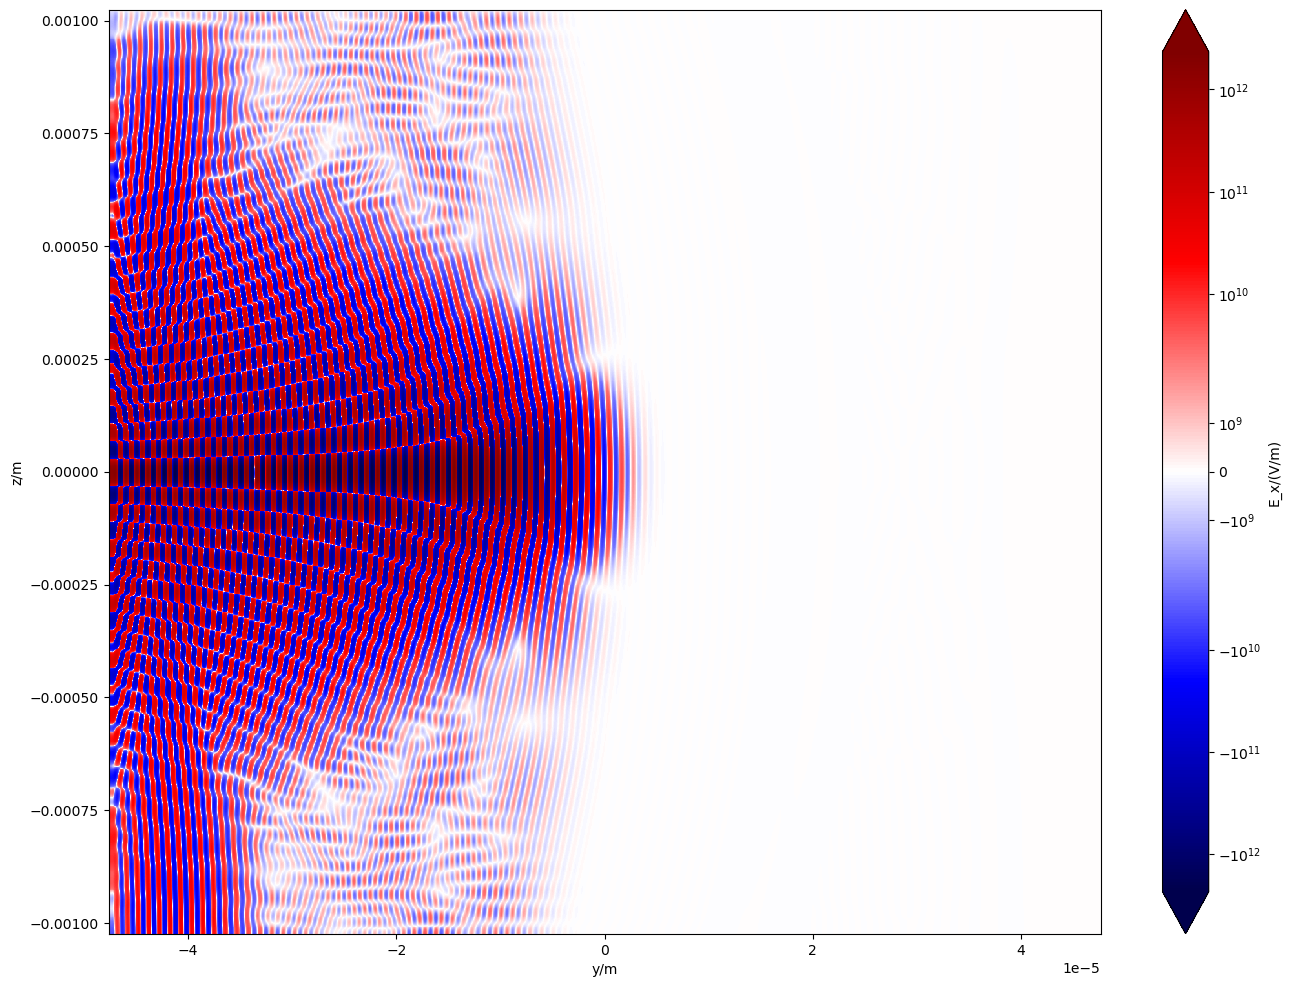

time showing file: 30.762 s
iteration: 1164000
absolute maximum: 2327764500000.0


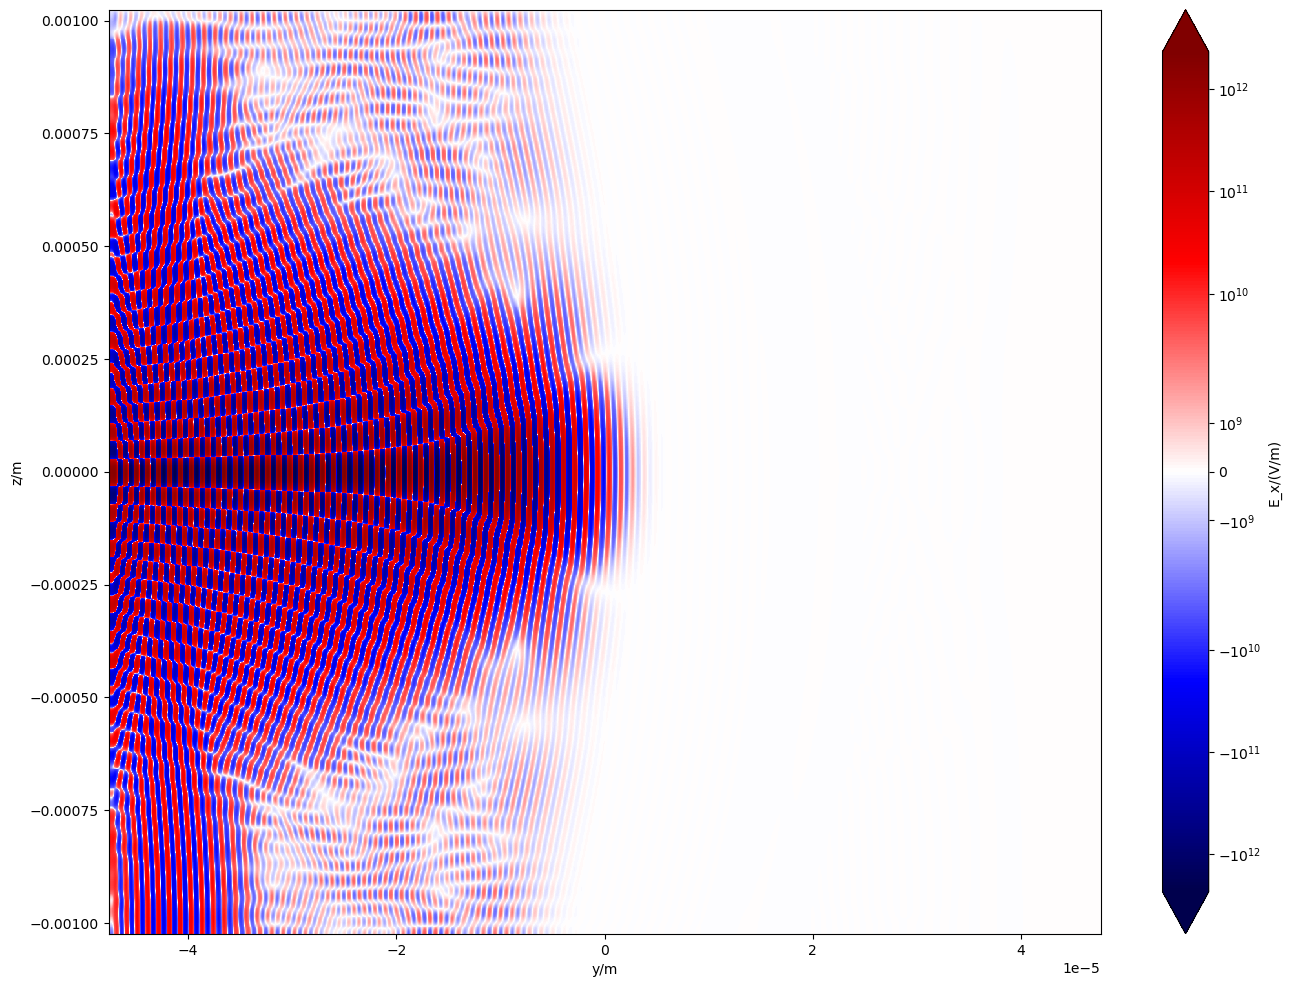

time showing file: 33.114 s
iteration: 1170000
absolute maximum: 2313217000000.0


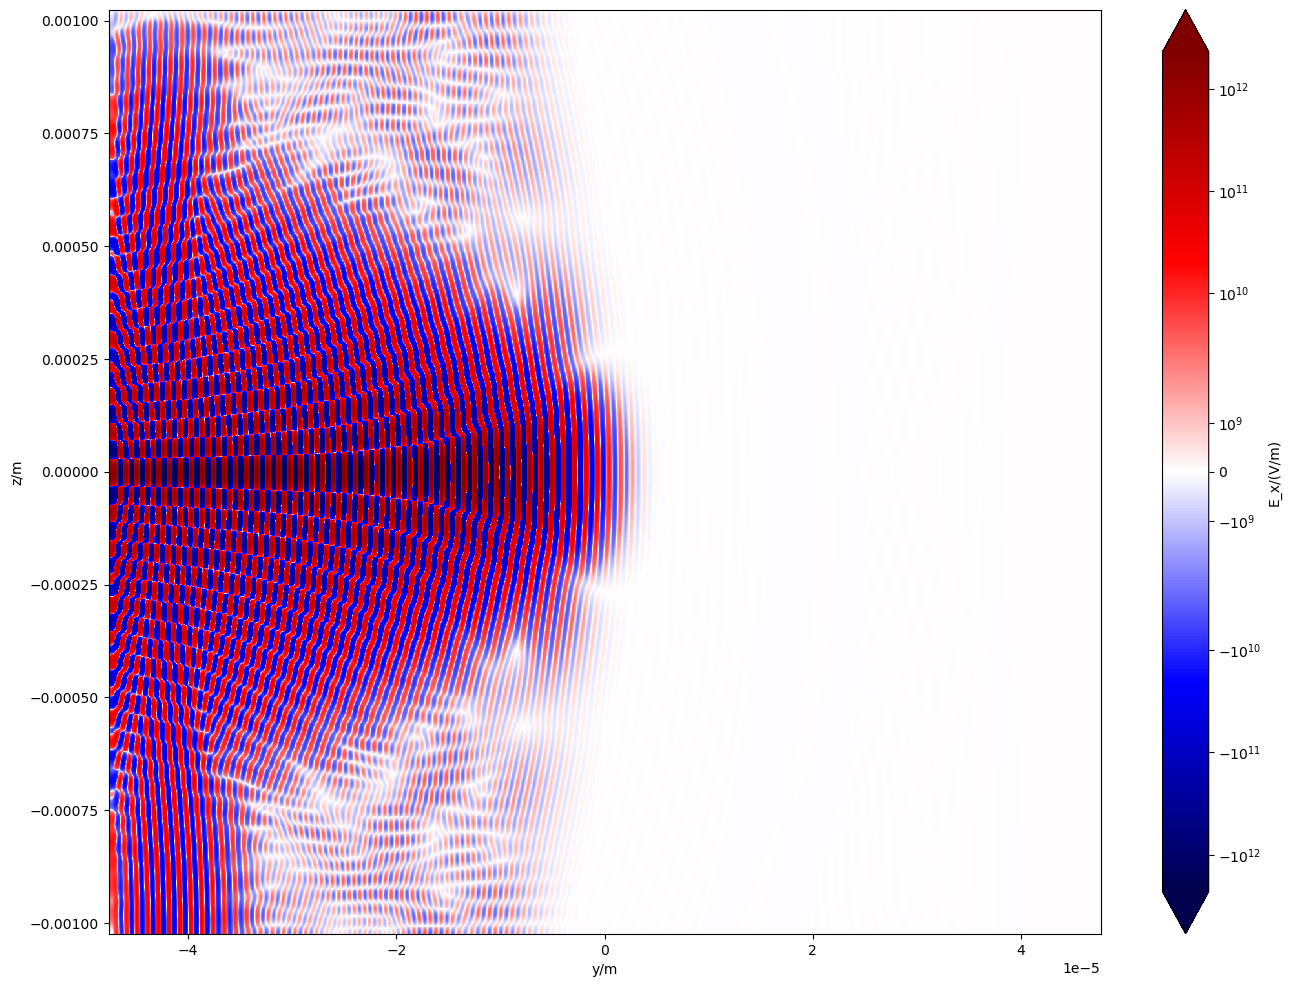

time showing file: 35.614 s
iteration: 1176000
absolute maximum: 2298158800000.0


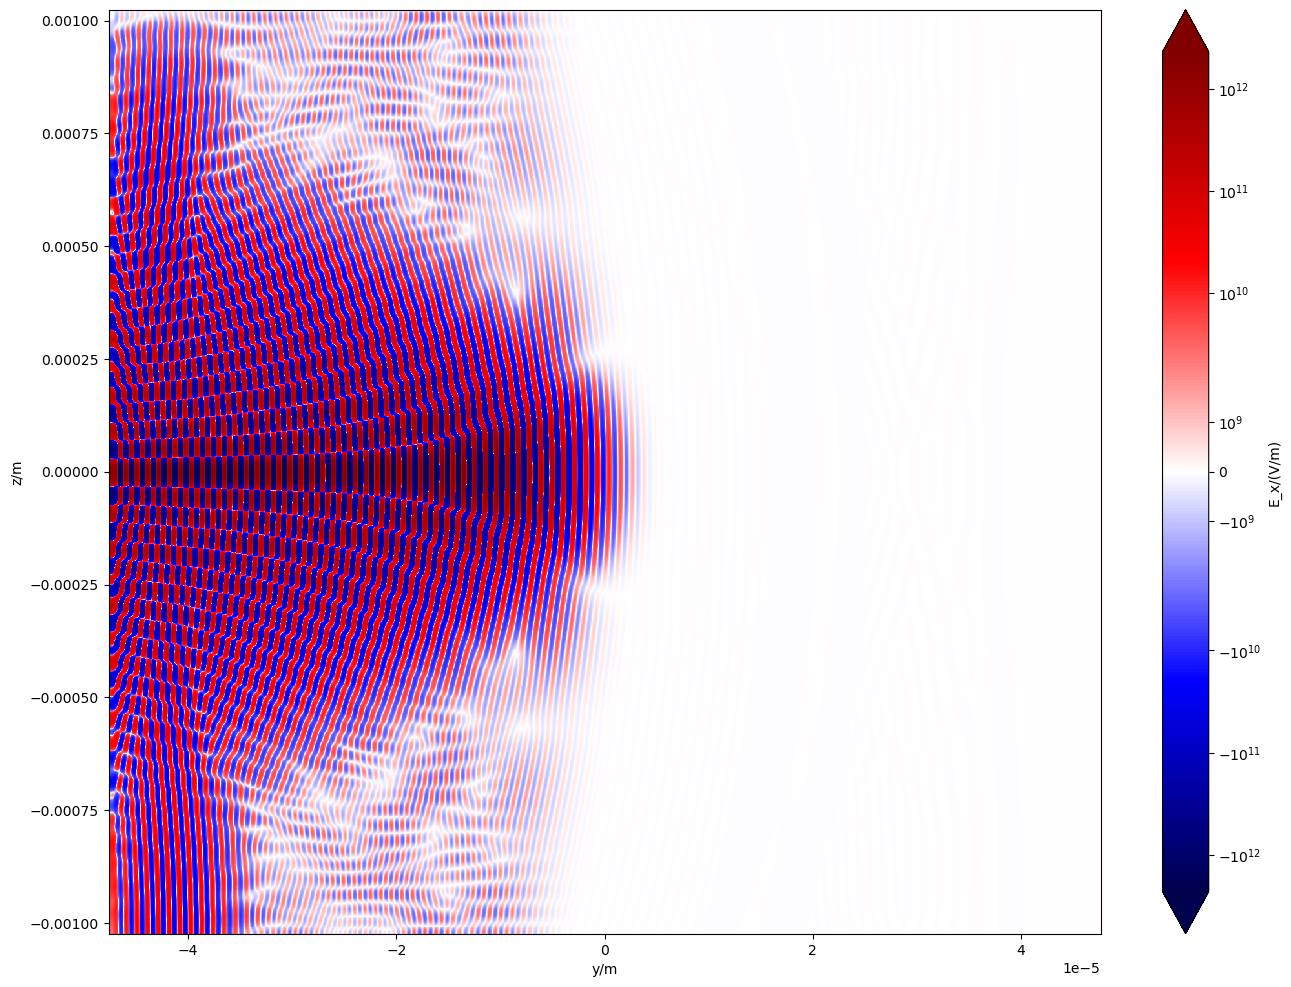

time showing file: 37.669 s
runtime: 39.074 s


In [2]:
showdata.show_file(filename, itstep=6000, forward="y", show_time=True, linthresh_frac=0.001)
ptime.ptime()

In [3]:
from scipy.constants import c
import axiparabola_theory as axi
from lasy.optical_elements import Axiparabola
delta = 2e-3
f0 = 7e-2
w = 1e-3
R = 1.7*w

calculating w


  0%|          | 00:00<? [?it/s]

maxtime reached
plotting w


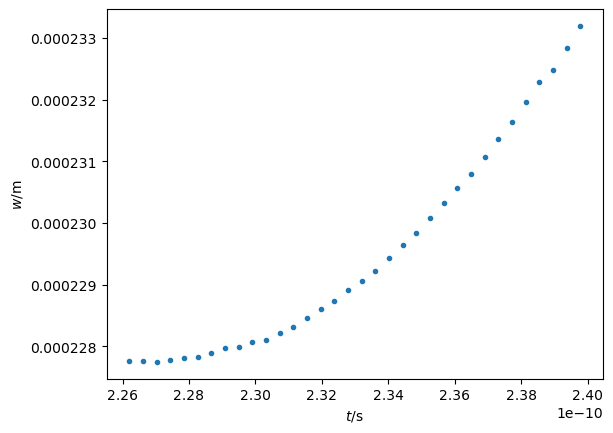

runtime: 42 min 7.8360 s


In [4]:
# showdata.show_metadata(filename, iteration=6000)

def shouldbe(t):
    """theoretical w"""
    l_w = 10.54e-7
    return axi.wtf(t+f0/c, Axiparabola(f0, delta, R), l_w)
showdata.plot_w(filename=filename, forward="y", startit=1, comp_func=None, maxtime=axi.tfz((f0+delta) * (1-1e-7), Axiparabola(f0, delta, R)))
ptime.ptime()

calculating lpeak


  0%|          | 00:00<? [?it/s]

maxtime reached
plotting lpeak


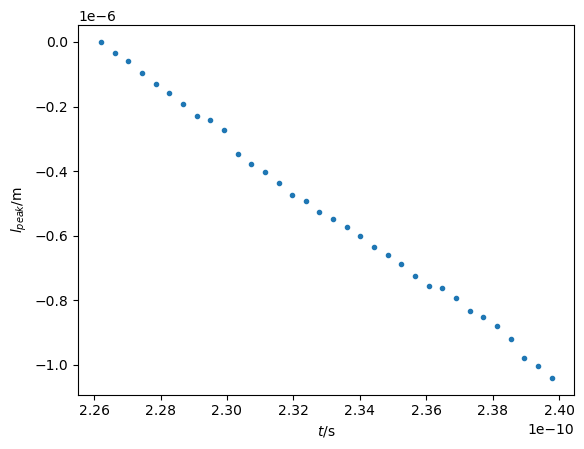

runtime: 1 h 25 min 34.924 s


In [5]:

def shouldbe2(t):
    """theoretical value"""
    l_w = 10.54e-7
    tau = 1.5e-14
    return axi.ztf(t+f0/c, Axiparabola(f0, delta, R))-f0-c*t
showdata.plot_lpeak(filename=filename, forward="y", startit=1, 
                    comp_func=None, maxtime=axi.tfz((f0+delta) * (1-2e-7), Axiparabola(f0, delta, R)),
                   apply_maxtime_to_measurement=True)
ptime.ptime()